# In-Class Practice: Data Preparation, Missing Values, and Regression

**MSDS 640 — Session 1**

In this notebook we will walk through a unified workflow that covers three core data science skills:

1. **Data Preparation** — loading, exploring, transforming, and standardizing data
2. **Handling Missing Values** — detecting, imputing, and removing incomplete records
3. **Regression Analysis** — training, evaluating, and comparing regression models

We will use the **Boston Housing Dataset** throughout so you can see how these steps connect in a single end-to-end pipeline.

---
## Part 1: Data Preparation

Before any modeling, we need to understand and prepare our data. This includes:
- Loading the data into a structured format (Pandas DataFrame)
- Inspecting shape, types, and summary statistics
- Normalizing / standardizing features

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### 1.1 Load the Boston Housing Dataset

The Boston Housing dataset contains 506 instances with 13 predictor variables and 1 target variable (MEDV — median home value in $1000s).

In [ ]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Create a mock 'boston' object similar to the original load_boston output
class BostonDataset:
    def __init__(self, data, target):
        self.data = data
        self.target = target
        # These are the original feature names from the boston dataset
        self.feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
        self.DESCR = "Boston Housing Dataset (fetched from original source due to scikit-learn removal)"

boston = BostonDataset(data, target)

print(boston.DESCR[:1000])

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1753/343124659.py:5: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


Boston Housing Dataset (fetched from original source due to scikit-learn removal)


In [ ]:
print(boston.DESCR[:1000])

Boston Housing Dataset (fetched from original source due to scikit-learn removal)


In [ ]:
# Create a DataFrame for easier manipulation
bostonDF = pd.DataFrame(boston.data, columns=boston.feature_names)
bostonDF['MEDV'] = boston.target

print("Shape:", bostonDF.shape)
bostonDF.head()

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


### 1.2 Inspect the Data

In [ ]:
# Check data types and non-null counts
bostonDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [ ]:
# Summary statistics for all numeric columns
bostonDF.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [ ]:
# Check column types
bostonDF.dtypes

,0
CRIM,float64
ZN,float64
INDUS,float64
CHAS,float64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,float64
TAX,float64


### 1.3 Visualize Distributions

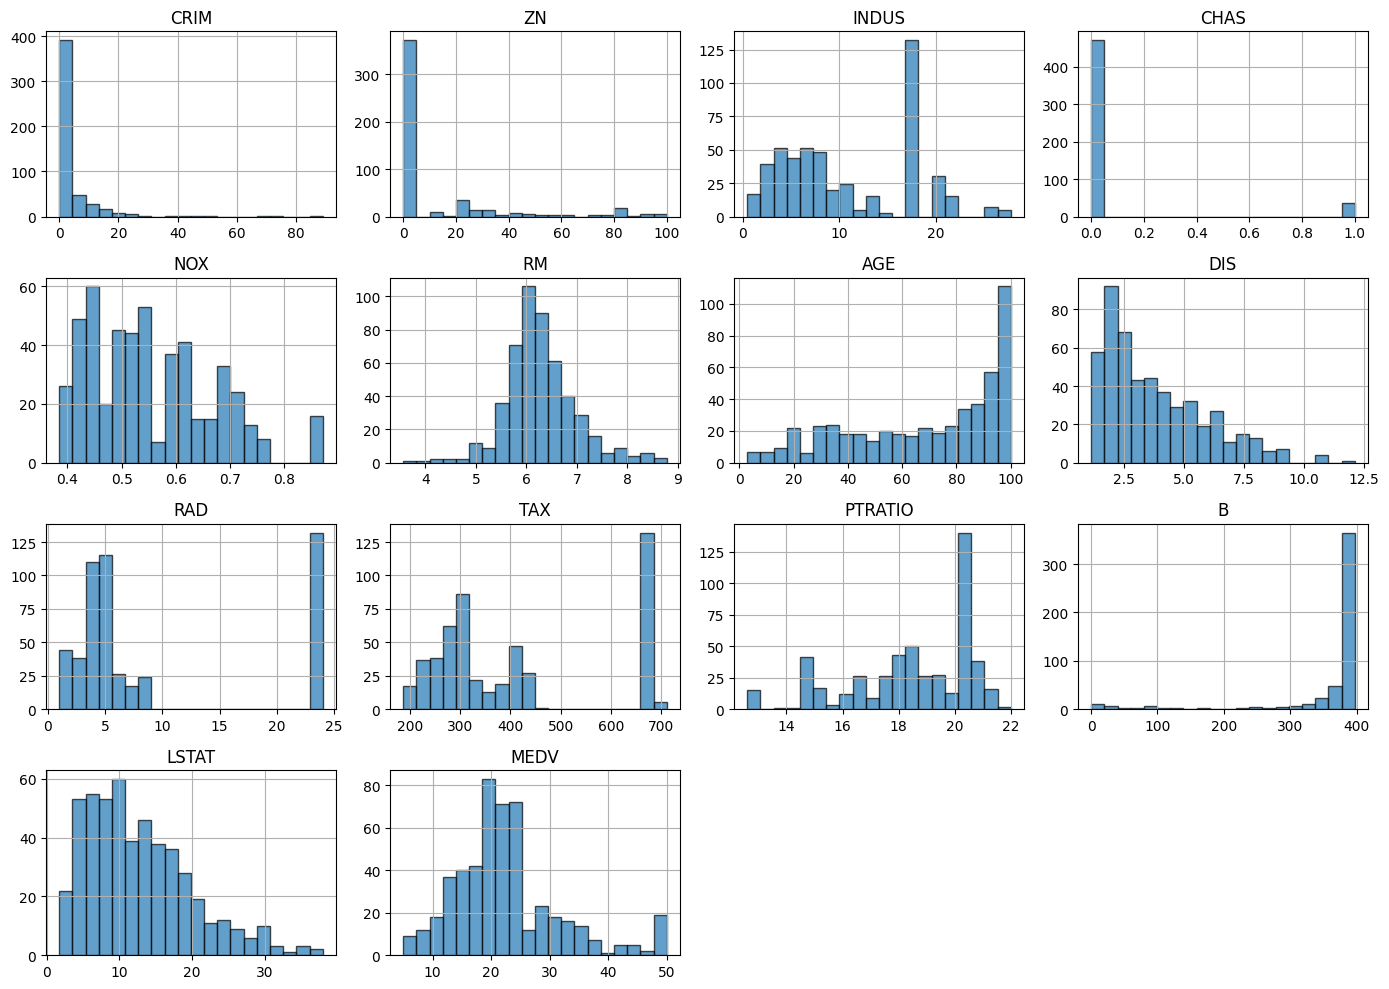

In [ ]:
# Histograms of all features
bostonDF.hist(figsize=(14, 10), bins=20, edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()

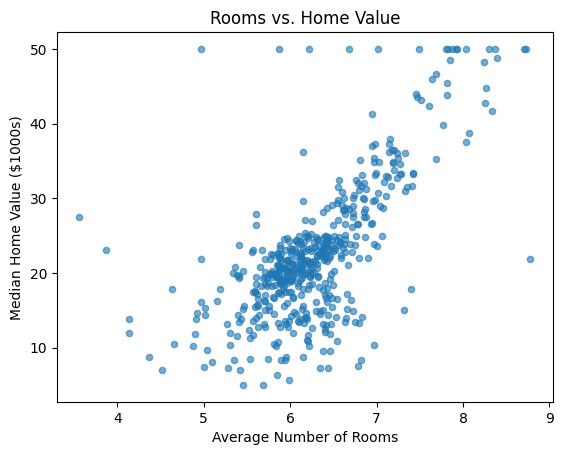

In [ ]:
# Scatter plot: RM (rooms) vs MEDV (price)
bostonDF.plot(x="RM", y="MEDV", kind="scatter", alpha=0.6)
plt.xlabel("Average Number of Rooms")
plt.ylabel("Median Home Value ($1000s)")
plt.title("Rooms vs. Home Value")
plt.show()

### 1.4 Feature Scaling / Standardization

Many ML algorithms (especially gradient-based methods) are sensitive to feature scales. We apply **Z-score standardization** so each feature has mean=0 and std=1.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = bostonDF.drop('MEDV', axis=1).values
y = bostonDF['MEDV'].values
feature_names = boston.feature_names

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (506, 13)
y shape: (506,)


In [ ]:
# Z-score standardization (manually, to understand what it does)
X_df = pd.DataFrame(X, columns=feature_names)
X_standardized = (X_df - X_df.mean()) / X_df.std()

print("Before standardization — mean of first 3 features:")
print(X_df[['CRIM', 'ZN', 'INDUS']].mean().values)
print("\nAfter standardization — mean of first 3 features:")
print(X_standardized[['CRIM', 'ZN', 'INDUS']].mean().values)
print("\nAfter standardization — std of first 3 features:")
print(X_standardized[['CRIM', 'ZN', 'INDUS']].std().values)

Before standardization — mean of first 3 features:
[ 3.61352356 11.36363636 11.13677866]

After standardization — mean of first 3 features:
[-1.12338772e-16  6.31905595e-17  2.52762238e-16]

After standardization — std of first 3 features:
[1. 1. 1.]


In [ ]:
# Using sklearn's StandardScaler (preferred in practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature means (should be ~0):", X_scaled.mean(axis=0)[:5].round(4))
print("Scaled feature stds (should be ~1):", X_scaled.std(axis=0)[:5].round(4))

Scaled feature means (should be ~0): [-0.  0.  0. -0. -0.]
Scaled feature stds (should be ~1): [1. 1. 1. 1. 1.]


### 1.5 Min-Max Normalization (Alternative)

Scales features to the [0, 1] range.

In [ ]:
# Min-Max normalization on a single feature
rm_min = bostonDF['RM'].min()
rm_max = bostonDF['RM'].max()
rm_normalized = (bostonDF['RM'] - rm_min) / (rm_max - rm_min)

print("RM original range: [{:.2f}, {:.2f}]".format(rm_min, rm_max))
print("RM normalized range: [{:.2f}, {:.2f}]".format(rm_normalized.min(), rm_normalized.max()))
rm_normalized.head()

---
## Part 2: Handling Missing Values

Real-world datasets often have missing values. We need strategies to deal with them before modeling.

We will first demonstrate with the Video Store dataset, then **intentionally inject missing values** into the Boston data to practice the full pipeline.

### 2.1 Example: Video Store Dataset with Missing Values

In [ ]:
# Load the Video Store dataset that has missing values
vstable = pd.read_csv("Video_Store_3.csv", index_col=0, na_values=["?"])
print("Shape:", vstable.shape)
vstable.head(10)

Shape: (50, 7)


,Gender,Income,Age,Rentals,Avg Per Visit,Genre,Incidentals
Cust ID,,,,,,,
1,M,45000,25.0,32,2.5,Action,Yes
2,F,54000,33.0,12,3.4,Drama,No
3,F,32000,NaN,42,1.6,Comedy,No
4,NaN,59000,70.0,16,4.2,Drama,Yes
5,M,37000,35.0,25,3.2,Action,Yes
6,M,18000,20.0,29,1.7,Action,No
7,F,29000,NaN,19,3.8,Drama,No
8,M,74000,25.0,31,2.4,Action,Yes
9,NaN,38000,21.0,18,2.1,Comedy,No


In [ ]:
# Check which columns have missing values
vstable.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 1 to 50
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Gender         45 non-null     object 
 1   Income         50 non-null     int64  
 2   Age            43 non-null     float64
 3   Rentals        50 non-null     int64  
 4   Avg Per Visit  50 non-null     float64
 5   Genre          50 non-null     object 
 6   Incidentals    50 non-null     object 
dtypes: float64(2), int64(2), object(3)
memory usage: 3.1+ KB


In [ ]:
# Boolean mask showing where NaN values are
vstable.isnull().sum()

,0
Gender,5
Income,0
Age,7
Rentals,0
Avg Per Visit,0
Genre,0
Incidentals,0


In [ ]:
# Show only rows that have at least one missing value
vstable[vstable.isnull().any(axis=1)]

,Gender,Income,Age,Rentals,Avg Per Visit,Genre,Incidentals
Cust ID,,,,,,,
3,F,32000,NaN,42,1.6,Comedy,No
4,NaN,59000,70.0,16,4.2,Drama,Yes
7,F,29000,NaN,19,3.8,Drama,No
9,NaN,38000,21.0,18,2.1,Comedy,No
14,M,45000,NaN,24,2.7,Drama,No
15,NaN,68000,30.0,36,2.7,Comedy,Yes
23,F,2000,NaN,30,2.5,Comedy,No
25,NaN,1000,16.0,25,1.4,Comedy,Yes
31,F,49000,NaN,15,3.2,Comedy,No


### 2.2 Strategy 1: Fill with Mean (Numeric Columns)

In [ ]:
# Fill missing Age values with the column mean
age_mean = vstable['Age'].mean()
print("Mean Age:", age_mean)

vstable['Age'].fillna(age_mean, inplace=True)

# Verify: no more NaN in Age
print("\nAge null count after fill:", vstable['Age'].isnull().sum())
vstable.head(10)

Mean Age: 30.930232558139537

Age null count after fill: 0


/tmp/ipykernel_1753/3906339065.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  vstable['Age'].fillna(age_mean, inplace=True)


,Gender,Income,Age,Rentals,Avg Per Visit,Genre,Incidentals
Cust ID,,,,,,,
1,M,45000,25.000000,32,2.5,Action,Yes
2,F,54000,33.000000,12,3.4,Drama,No
3,F,32000,30.930233,42,1.6,Comedy,No
4,NaN,59000,70.000000,16,4.2,Drama,Yes
5,M,37000,35.000000,25,3.2,Action,Yes
6,M,18000,20.000000,29,1.7,Action,No
7,F,29000,30.930233,19,3.8,Drama,No
8,M,74000,25.000000,31,2.4,Action,Yes
9,NaN,38000,21.000000,18,2.1,Comedy,No


### 2.3 Strategy 2: Drop Rows with Missing Values

In [ ]:
# Drop rows where Gender is missing
print("Before dropping:", vstable.shape)
vstable.drop(vstable[vstable.Gender.isnull()].index, axis=0, inplace=True)
print("After dropping:", vstable.shape)

Before dropping: (50, 7)
After dropping: (45, 7)


In [ ]:
# Alternative: dropna() removes ALL rows with any NaN
# vstable.dropna(axis=0, inplace=True)

### 2.4 Applying to Boston Data — Simulate Missing Values

Let's intentionally introduce missing values into the Boston dataset and practice handling them before regression.

In [ ]:
# Create a copy and randomly insert NaN values
np.random.seed(42)
bostonDF_missing = bostonDF.copy()

# Randomly set 5% of values to NaN in selected columns
cols_to_corrupt = ['CRIM', 'RM', 'AGE', 'LSTAT']
for col in cols_to_corrupt:
    mask = np.random.random(len(bostonDF_missing)) < 0.05
    bostonDF_missing.loc[mask, col] = np.nan

print("Missing values per column:")
print(bostonDF_missing.isnull().sum())
print("\nTotal rows with at least one NaN:", bostonDF_missing.isnull().any(axis=1).sum())

Missing values per column:
CRIM       31
ZN          0
INDUS       0
CHAS        0
NOX         0
RM         23
AGE        32
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      21
MEDV        0
dtype: int64

Total rows with at least one NaN: 101


In [ ]:
# Strategy: Fill numeric missing values with the column median
# (median is more robust to outliers than mean)

for col in cols_to_corrupt:
    median_val = bostonDF_missing[col].median()
    bostonDF_missing[col].fillna(median_val, inplace=True)

print("After imputation — missing values per column:")
print(bostonDF_missing.isnull().sum())

After imputation — missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


/tmp/ipykernel_1753/86888764.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bostonDF_missing[col].fillna(median_val, inplace=True)


In [ ]:
# Verify the imputed data looks reasonable
bostonDF_missing.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.493156,8.593005,0.00632,0.086747,0.25915,2.808720,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.287818,0.692414,3.56100,5.896500,6.20900,6.601750,8.7800
AGE,506.0,68.891897,27.350578,2.90000,46.825000,76.95000,93.300000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


---
## Part 3: Regression Analysis

Now that our data is prepared and complete, we can build regression models to predict MEDV (home values).

We will:
1. Split into train/test sets
2. Train a basic Linear Regression model
3. Evaluate with RMSE
4. Try Ridge and Lasso regularization
5. Compare models

### 3.1 Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Use the imputed data
X = bostonDF_missing.drop('MEDV', axis=1).values
y = bostonDF_missing['MEDV'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=111)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 404
Test set size: 102


### 3.2 Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Train the model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predictions
p_train = linreg.predict(X_train)
p_test = linreg.predict(X_test)

# Evaluate
rmse_train = np.sqrt(mean_squared_error(y_train, p_train))
rmse_test = np.sqrt(mean_squared_error(y_test, p_test))
mae_test = mean_absolute_error(y_test, p_test)

print("Linear Regression Results:")
print("  RMSE on Training: {:.4f}".format(rmse_train))
print("  RMSE on Test:     {:.4f}".format(rmse_test))
print("  MAE on Test:      {:.4f}".format(mae_test))

Linear Regression Results:
  RMSE on Training: 4.6876
  RMSE on Test:     4.9683
  MAE on Test:      3.4641


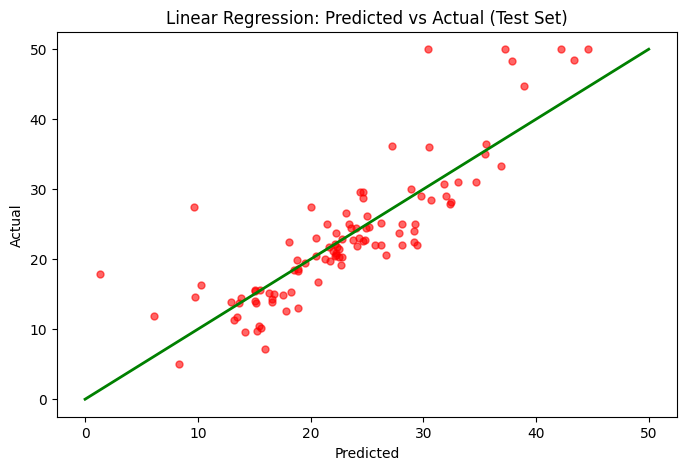

In [ ]:
# Visualize: Predicted vs Actual
plt.figure(figsize=(8, 5))
plt.plot(p_test, y_test, 'ro', markersize=5, alpha=0.6)
plt.plot([0, 50], [0, 50], 'g-', linewidth=2)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Linear Regression: Predicted vs Actual (Test Set)')
plt.show()

In [ ]:
# Model coefficients
print("Intercept: {:.4f}".format(linreg.intercept_))
print("\nFeature Coefficients:")
for name, coef in zip(feature_names, linreg.coef_):
    print("  {:>8s}: {:+.4f}".format(name, coef))

Intercept: 27.0088

Feature Coefficients:
      CRIM: -0.1018
        ZN: +0.0484
     INDUS: +0.0398
      CHAS: +2.3938
       NOX: -16.3874
        RM: +4.9366
       AGE: -0.0234
       DIS: -1.4219
       RAD: +0.2655
       TAX: -0.0124
   PTRATIO: -0.9085
         B: +0.0108
     LSTAT: -0.3803


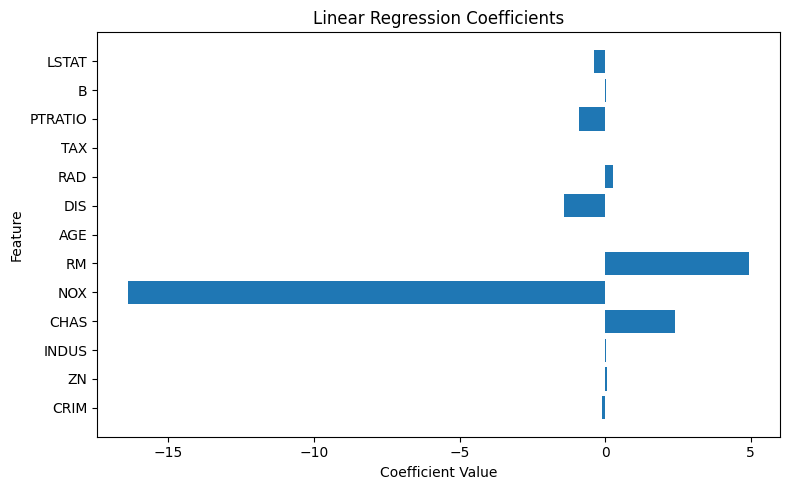

In [ ]:
# Plot coefficients
import pylab as pl

def plot_coefficients(model, n_features, feature_names):
    pl.figure(figsize=(8, 5))
    pl.barh(range(n_features), model.coef_, align='center')
    pl.yticks(np.arange(n_features), feature_names)
    pl.xlabel("Coefficient Value")
    pl.ylabel("Feature")
    pl.title("Linear Regression Coefficients")
    pl.ylim(-1, n_features)
    pl.tight_layout()
    pl.show()

plot_coefficients(linreg, len(feature_names), feature_names)

### 3.3 Cross-Validation

We use K-Fold cross-validation to get a more reliable estimate of model performance.

In [ ]:
from sklearn.model_selection import KFold

def cross_validate(model, X, y, n, verbose=False):
    """Compute mean RMSE across n-fold cross-validation."""
    kf = KFold(n_splits=n, random_state=22, shuffle=True)
    xval_err = 0
    f = 1
    for train_idx, test_idx in kf.split(X):
        model.fit(X[train_idx], y[train_idx])
        p = model.predict(X[test_idx])
        rmse = np.sqrt(mean_squared_error(y[test_idx], p))
        if verbose:
            print("  Fold {:2d} RMSE: {:.4f}".format(f, rmse))
        xval_err += rmse
        f += 1
    return xval_err / n

print("10-Fold Cross-Validation (Linear Regression):")
rmse_cv = cross_validate(linreg, X_train, y_train, 10, verbose=True)
print("\n  Mean RMSE: {:.4f}".format(rmse_cv))

10-Fold Cross-Validation (Linear Regression):
  Fold  1 RMSE: 4.9059
  Fold  2 RMSE: 4.1731
  Fold  3 RMSE: 6.8387
  Fold  4 RMSE: 5.7901
  Fold  5 RMSE: 5.7754
  Fold  6 RMSE: 3.6950
  Fold  7 RMSE: 3.7721
  Fold  8 RMSE: 4.1257
  Fold  9 RMSE: 5.3413
  Fold 10 RMSE: 4.4232

  Mean RMSE: 4.8840


### 3.4 Ridge Regression (L2 Regularization)

Ridge adds a penalty term to prevent large coefficients (reduces overfitting).

In [ ]:
from sklearn.linear_model import Ridge

# Try different alpha values
print("Ridge Regression — Alpha Tuning:")
print("{:>8s}  {:>12s}  {:>12s}  {:>8s}".format("Alpha", "RMSE_Train", "RMSE_CV", "Gap"))
print("-" * 46)

alphas = [0.01, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]
best_alpha = 0.01
best_cv = 999

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    p = ridge.predict(X_train)
    rmse_t = np.sqrt(mean_squared_error(y_train, p))
    rmse_cv = cross_validate(ridge, X_train, y_train, 10)
    gap = rmse_cv - rmse_t
    print("{:8.2f}  {:12.4f}  {:12.4f}  {:8.4f}".format(a, rmse_t, rmse_cv, gap))
    if rmse_cv < best_cv:
        best_cv = rmse_cv
        best_alpha = a

print("\nBest alpha: {:.2f} (CV RMSE: {:.4f})".format(best_alpha, best_cv))

Ridge Regression — Alpha Tuning:
   Alpha    RMSE_Train       RMSE_CV       Gap
----------------------------------------------
    0.01        4.6876        4.8838    0.1962
    0.10        4.6881        4.8819    0.1938
    0.25        4.6901        4.8810    0.1909
    0.50        4.6950        4.8823    0.1873
    1.00        4.7052        4.8878    0.1826
    2.00        4.7209        4.8976    0.1767
    5.00        4.7442        4.9112    0.1669

Best alpha: 0.25 (CV RMSE: 4.8810)


In [ ]:
# Train final Ridge model with best alpha
ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(X_train, y_train)

p_test_ridge = ridge_final.predict(X_test)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, p_test_ridge))
print("Ridge Regression (alpha={:.2f}):".format(best_alpha))
print("  RMSE on Test: {:.4f}".format(rmse_test_ridge))

Ridge Regression (alpha=0.25):
  RMSE on Test: 4.9843


### 3.5 Lasso Regression (L1 Regularization)

Lasso can shrink some coefficients to exactly zero, performing feature selection.

In [ ]:
from sklearn.linear_model import Lasso

print("Lasso Regression — Alpha Tuning:")
print("{:>8s}  {:>12s}  {:>12s}  {:>8s}".format("Alpha", "RMSE_Train", "RMSE_CV", "Gap"))
print("-" * 46)

alphas_lasso = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0]
best_alpha_l = 0.01
best_cv_l = 999

for a in alphas_lasso:
    lasso = Lasso(alpha=a)
    lasso.fit(X_train, y_train)
    p = lasso.predict(X_train)
    rmse_t = np.sqrt(mean_squared_error(y_train, p))
    rmse_cv = cross_validate(lasso, X_train, y_train, 10)
    gap = rmse_cv - rmse_t
    print("{:8.2f}  {:12.4f}  {:12.4f}  {:8.4f}".format(a, rmse_t, rmse_cv, gap))
    if rmse_cv < best_cv_l:
        best_cv_l = rmse_cv
        best_alpha_l = a

print("\nBest alpha: {:.2f} (CV RMSE: {:.4f})".format(best_alpha_l, best_cv_l))

Lasso Regression — Alpha Tuning:
   Alpha    RMSE_Train       RMSE_CV       Gap
----------------------------------------------
    0.01        4.6916        4.8853    0.1937
    0.05        4.7751        4.9422    0.1671
    0.10        4.7887        4.9517    0.1630
    0.30        4.8402        4.9625    0.1224
    0.50        4.9007        5.0203    0.1195
    1.00        5.1750        5.2769    0.1018
    2.00        5.8395        5.8902    0.0507

Best alpha: 0.01 (CV RMSE: 4.8853)


In [ ]:
# Train final Lasso model
lasso_final = Lasso(alpha=best_alpha_l)
lasso_final.fit(X_train, y_train)

p_test_lasso = lasso_final.predict(X_test)
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, p_test_lasso))
print("Lasso Regression (alpha={:.2f}):".format(best_alpha_l))
print("  RMSE on Test: {:.4f}".format(rmse_test_lasso))

# Show which features Lasso zeroed out
print("\nLasso Coefficients (features with 0 are eliminated):")
for name, coef in zip(feature_names, lasso_final.coef_):
    marker = " <-- eliminated" if abs(coef) < 0.001 else ""
    print("  {:>8s}: {:+.4f}{}".format(name, coef, marker))

Lasso Regression (alpha=0.01):
  RMSE on Test: 4.9912

Lasso Coefficients (features with 0 are eliminated):
      CRIM: -0.1001
        ZN: +0.0482
     INDUS: +0.0247
      CHAS: +2.2285
       NOX: -12.8714
        RM: +4.9501
       AGE: -0.0260
       DIS: -1.3603
       RAD: +0.2559
       TAX: -0.0126
   PTRATIO: -0.8751
         B: +0.0111
     LSTAT: -0.3847


### 3.6 Model Comparison

MODEL COMPARISON — Test Set RMSE
  Linear Regression:   4.9683
  Ridge (alpha=0.25):    4.9843
  Lasso (alpha=0.01):    4.9912


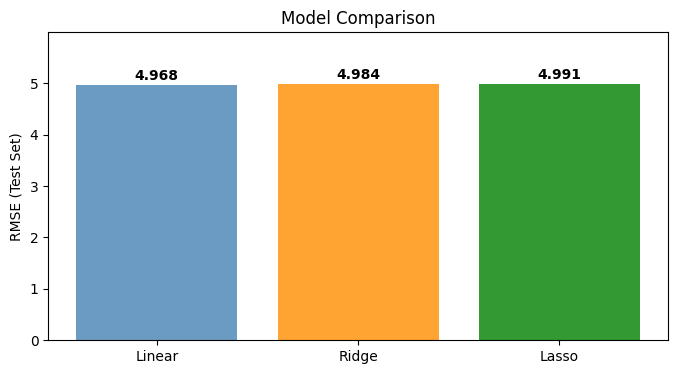

In [ ]:
# Summary table
print("=" * 50)
print("MODEL COMPARISON — Test Set RMSE")
print("=" * 50)
print("  Linear Regression:   {:.4f}".format(rmse_test))
print("  Ridge (alpha={:.2f}):    {:.4f}".format(best_alpha, rmse_test_ridge))
print("  Lasso (alpha={:.2f}):    {:.4f}".format(best_alpha_l, rmse_test_lasso))
print("=" * 50)

# Visual comparison
models = ['Linear', 'Ridge', 'Lasso']
rmses = [rmse_test, rmse_test_ridge, rmse_test_lasso]

plt.figure(figsize=(8, 4))
plt.bar(models, rmses, color=['steelblue', 'darkorange', 'green'], alpha=0.8)
plt.ylabel('RMSE (Test Set)')
plt.title('Model Comparison')
plt.ylim(0, max(rmses) * 1.2)
for i, v in enumerate(rmses):
    plt.text(i, v + 0.1, "{:.3f}".format(v), ha='center', fontweight='bold')
plt.show()

---
## Summary

In this practice session we covered the full pipeline:

| Step | What We Did |
|------|-------------|
| **Data Preparation** | Loaded data, inspected types/shape, visualized distributions, standardized features |
| **Missing Values** | Detected NaN values, imputed with mean/median, dropped rows when appropriate |
| **Regression** | Split data, trained Linear/Ridge/Lasso models, evaluated with RMSE, compared performance |

**Key Takeaways:**
- Always explore and prepare your data before modeling
- Choose your missing value strategy based on the amount and pattern of missingness
- Regularization (Ridge/Lasso) can improve generalization — tune the alpha parameter
- Use cross-validation to get reliable performance estimates, not just a single train/test split

---
## Your Turn!

**Exercise:** Try the following on your own:
1. Use `ElasticNet` regression (combines Ridge + Lasso). What alpha and l1_ratio work best?
2. Apply `StandardScaler` before regression — does it improve SGD-based regression?
3. Instead of median imputation, try `sklearn.impute.SimpleImputer` with strategy='most_frequent' for categorical data
4. Try a different random_state for the train/test split — how stable are your results?